In [ ]:
%cd E:\SRP\SRP-2025-Project
import os,sys
notebook_dir = os.getcwd()
path = os.path.abspath(os.path.join(notebook_dir, "Code/CMC Model"))
sys.path.append(path)
import optuna
import optunahub
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score,roc_curve,classification_report
from generateSplits import generateSplits
import pandas as pd
from trainModel import trainModel
from Dataset import ModelDataset
from model import Model
from torch.utils.data import DataLoader
import torch
import matplotlib.pyplot as plt
from optuna.storages import RDBStorage,RetryFailedTrialCallback
import logging
import gc

E:\SRP\SRP-2025-Project


In [2]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

metadata = pd.read_csv("../Datasets/BreastDCEDL_spy1/BreastDCEDL_spy1_metadata.csv")
train_df,val_df = generateSplits(metadata,0.2,seed=42)
train_df = train_df[["pid","pCR","ER","PR","HER2"]].set_index("pid",drop=True)
val_df = val_df[["pid","pCR","ER","PR","HER2"]].set_index("pid",drop=True)
skf = StratifiedKFold(n_splits=4,shuffle=True,random_state=42)
backup_path = "study_backup.db"

In [3]:
def evaluate(model:torch.nn.Module,val_loader:torch.utils.data.DataLoader):
    model.eval()
    model.to(device)
    
    y_score = []
    y_true = []
    y_pred = []
    with torch.no_grad():
        for images,mols,labels in val_loader:
            images = images.to(device)
            mols = mols.to(device)
            logits = model(images,mols)
            scores = torch.nn.functional.softmax(logits,dim=1)[:,1]
            y_score.extend(scores.cpu().numpy())
            y_true.extend(labels.cpu().numpy())
    
    return roc_auc_score(y_true,y_score)
  

In [4]:
with open("Code/url.txt","r") as f:
    url = f.read()

storage = RDBStorage(
    url=url,
)


module = optunahub.load_module(package="samplers/auto_sampler")

#sampler = optuna.samplers.RandomSampler()
#sampler = optuna.samplers.CmaEsSampler()
sampler = module.AutoSampler()
pruner = optuna.pruners.MedianPruner(n_startup_trials=5,n_warmup_steps=2,)

optuna_logger = optuna.logging.get_logger("optuna")

# Remove all handlers
for handler in optuna_logger.handlers[:]:  # make a copy of the list
    optuna_logger.removeHandler(handler)

optuna.logging.get_logger("optuna").addHandler(logging.StreamHandler(sys.stdout))

study = optuna.create_study(
    storage=storage,
    sampler = sampler,
    pruner=pruner,
    study_name="SRP_Model_Study",
    load_if_exists=True,
    direction="maximize")

Using an existing study with name 'SRP_Model_Study' instead of creating a new one.


In [5]:
def objective(trial:optuna.Trial):
    print(f"Using device: {device}")
    print(f"Sampler: {study.sampler._sampler}")
    optimisers = {"Adam":torch.optim.Adam,"SGD":torch.optim.SGD,"AdamW":torch.optim.AdamW}
    lr = trial.suggest_float("lr",1e-5,1e-1,log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-8, 1e-1, log=True)
    batch_size = trial.suggest_categorical("batch_size",[4,8,16,32,64,128])
    optimiser_name = trial.suggest_categorical("optimiser_name", ["Adam", "SGD","AdamW"])
    momentum = None  # Default value
    scheduler_factor = 1.0  # Default value
    if optimiser_name == "SGD":
        momentum = trial.suggest_float("momentum",0.0,1.0)
        scheduler_factor = trial.suggest_float("scheduler_factor",0.0,1.0)
    optimiser_class = optimisers[optimiser_name]
    
    scores = []
    
    for train_index,val_index in skf.split(train_df, train_df["pCR"]):
        fold_train_df = train_df.iloc[train_index]
        fold_val_df = train_df.iloc[val_index]
        fold_train_dataset = ModelDataset(fold_train_df,class_samples={0:3,1:8},loading_bar=False,caching=True)
        fold_train_loader = DataLoader(fold_train_dataset,batch_size=batch_size,shuffle=True)
        model = Model()
        if optimiser_name =="SGD":
            optimiser = optimiser_class(model.parameters(),lr=lr,weight_decay=weight_decay,momentum=momentum)
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='max', factor=scheduler_factor, patience=2)  
        else:
            optimiser = optimiser_class(model.parameters(),lr=lr,weight_decay=weight_decay)
            scheduler = None
        fold_val_dataset = ModelDataset(fold_val_df,class_samples={0:1,1:1},loading_bar=False,caching=True)
        fold_val_loader = DataLoader(fold_val_dataset,batch_size=batch_size)
        model,score = trainModel(model,fold_train_loader,optimiser,device=device,num_epochs=20,val_loader=fold_val_loader,patience=5,scheduler=scheduler)
        scores.append(score)
        print(f"ROC_AUC = {score}")
        
        trial.report(sum(scores)/len(scores),step=len(scores))
        print(f"Average score: {sum(scores)/len(scores)} after {len(scores)} folds")
        if trial.should_prune():
            raise optuna.TrialPruned()
 
        
    avg_score = sum(scores)/len(scores)
    print(avg_score)
    return avg_score

## Optimise Hyperparameters

In [21]:


study.optimize(objective,n_trials=3,show_progress_bar=True)




    
try:
    if os.path.exists(backup_path):
        os.remove(backup_path)
    optuna.copy_study(
        from_study_name="SRP_Model_Study",
        from_storage=storage,
        to_storage=f"sqlite:///{backup_path}"
    )
except PermissionError:
    print("PermissionError: deleting reference to study")
    for var in list(globals()):
        if isinstance(globals()[var], optuna.study.Study):
            s = globals()[var]
            # only delete if the study is backed by SQLite (not your Aiven storage)
            if isinstance(s._storage, optuna.storages.RDBStorage) and \
            str(s._storage.url).startswith("sqlite:///"):
                del globals()[var]
    gc.collect()
    if os.path.exists(backup_path):
        os.remove(backup_path)
    optuna.copy_study(
        from_study_name="SRP_Model_Study",
        from_storage=storage,
        to_storage=f"sqlite:///{backup_path}"
    )

  0%|          | 0/3 [00:00<?, ?it/s]

Using device: cuda
Sampler: TPESampler
Dataset initialised with 409 entries.
Dataset initialised with 31 entries.
Epoch 0 Done. Avg Loss: 2.2005
ROC_AUC: 0.6521739130434783
Epoch 1 Done. Avg Loss: 0.6887
ROC_AUC: 0.5543478260869565
Epoch 2 Done. Avg Loss: 0.6896
ROC_AUC: 0.5054347826086957
Epoch 3 Done. Avg Loss: 0.6974
ROC_AUC: 0.5217391304347827
Learning rate changed from [0.017426064563131387] to [0.013407451208820318]
Epoch 4 Done. Avg Loss: 0.6258
ROC_AUC: 0.483695652173913
Epoch 5 Done. Avg Loss: 0.6658
ROC_AUC: 0.44021739130434784
Early stopping triggered at epoch 5 (best AUC: 0.6522).
ROC_AUC = 0.6521739130434783
Average score: 0.6521739130434783 after 1 folds
Dataset initialised with 409 entries.
Dataset initialised with 31 entries.
Epoch 0 Done. Avg Loss: 2.4573
ROC_AUC: 0.4619565217391304
Epoch 1 Done. Avg Loss: 0.7051
ROC_AUC: 0.5380434782608696
Epoch 2 Done. Avg Loss: 0.7316
ROC_AUC: 0.5978260869565217
Epoch 3 Done. Avg Loss: 0.7009
ROC_AUC: 0.4565217391304348
Epoch 4 Done

[I 2025-09-09 18:46:10,695] A new study created in RDB with name: SRP_Model_Study


In [ ]:
study = optuna.load_study(study_name="SRP_Model_Study",storage=f"sqlite:///{backup_path}") 

In [5]:
print(f"Best params: {study.best_params}")
#Best params: {'lr': 0.010203264127576701, 'weight_decay': 0.004617603477095672, 'batch_size': 8, 'optimiser_name': 'Adam'}

Best params: {'lr': 0.010203264127576701, 'weight_decay': 0.004617603477095672, 'batch_size': 8, 'optimiser_name': 'Adam'}


## Train full model

In [7]:
optimisers = {"Adam":torch.optim.Adam,"SGD":torch.optim.SGD,"AdamW":torch.optim.AdamW}

params = study.best_trial.params
model = Model()

if params["optimiser_name"] in {"Adam","AdamW"}:
    optimiser_class = optimisers[params["optimiser_name"]]
    lr = params["lr"]
    weight_decay = params["weight_decay"]
    batch_size = params["batch_size"]
    optimiser = optimiser_class(params=model.parameters(),lr=lr,weight_decay=weight_decay)
train_dataset = ModelDataset(train_df,class_samples={0:1,1:1},loading_bar = False, caching=True)
train_loader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
val_dataset = ModelDataset(val_df,class_samples={0:1,1:1},loading_bar = False, caching=True)
val_loader = DataLoader(val_dataset,batch_size=batch_size)
model,score = trainModel(model,train_loader,optimiser,device=device,num_epochs=100,patience=20,val_loader=val_loader)
roc_auc = evaluate(model,val_loader)
print(f"ROC_AUC: {roc_auc}")
os.makedirs("best_params_without_rotation",exist_ok=True)
torch.save(model.state_dict(),"best_params_without_rotation/model_weights.pth")



Dataset initialised with 124 entries.
Dataset initialised with 32 entries.
Epoch 0 Done. Avg Loss: 54.3850
ROC_AUC: 0.4541062801932367
Epoch 1 Done. Avg Loss: 17.0836
ROC_AUC: 0.6280193236714976
Epoch 2 Done. Avg Loss: 9.4327
ROC_AUC: 0.33333333333333337
Epoch 3 Done. Avg Loss: 4.8913
ROC_AUC: 0.46376811594202905
Epoch 4 Done. Avg Loss: 7.5006
ROC_AUC: 0.427536231884058
Epoch 5 Done. Avg Loss: 3.6500
ROC_AUC: 0.3719806763285024
Epoch 6 Done. Avg Loss: 3.1159
ROC_AUC: 0.28019323671497587
Epoch 7 Done. Avg Loss: 1.1087
ROC_AUC: 0.25120772946859904
Epoch 8 Done. Avg Loss: 0.9858
ROC_AUC: 0.2995169082125604
Epoch 9 Done. Avg Loss: 1.0820
ROC_AUC: 0.3333333333333333
Epoch 10 Done. Avg Loss: 0.8482
ROC_AUC: 0.3864734299516908
Epoch 11 Done. Avg Loss: 0.7382
ROC_AUC: 0.3623188405797101
Epoch 12 Done. Avg Loss: 1.5753
ROC_AUC: 0.30434782608695654
Epoch 13 Done. Avg Loss: 3.1528
ROC_AUC: 0.4251207729468598
Epoch 14 Done. Avg Loss: 2.8625
ROC_AUC: 0.6521739130434783
Epoch 15 Done. Avg Loss: 1.29

In [11]:
if os.path.exists(backup_path):
    os.remove(backup_path)

optuna.copy_study(
    from_study_name="SRP_Model_Study",
    from_storage=storage,
    to_storage=f"sqlite:///{backup_path}"
)

A new study created in RDB with name: SRP_Model_Study


[I 2025-08-21 20:27:32,082] A new study created in RDB with name: SRP_Model_Study


### Free up backup study

In [10]:
for var in list(globals()):
    if isinstance(globals()[var], optuna.study.Study):
        s = globals()[var]
        # only delete if the study is backed by SQLite (not your Aiven storage)
        if isinstance(s._storage, optuna.storages.RDBStorage) and \
           str(s._storage.url).startswith("sqlite:///"):
            del globals()[var]

gc.collect()


7004

In [ ]:
def retry_failed_trials(study: optuna.Study, objective_func):
    failed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.FAIL]
    print(f"Found {len(failed_trials)} failed trials. Retrying...")

    for trial in failed_trials:
        print(f"Retrying trial #{trial.number} with params {trial.params}")

        def fixed_objective(trial_):
            trial_.set_user_attr("original_trial_number", trial.number)
            for key, value in trial.params.items():
                if isinstance(value, float):
                    trial_.suggest_float(key, value, value)  # no log param here
                elif isinstance(value, int):
                    trial_.suggest_int(key, value, value)
                else:
                    trial_.suggest_categorical(key, [value])
            return objective_func(trial_)

        study.optimize(fixed_objective, n_trials=1)

    print("Retried all failed trials.")


In [ ]:
retry_failed_trials(study,objective)

## Delete study

In [ ]:
with open("Code/url.txt","r") as f:
    url = f.read()

storage = RDBStorage(
    url=url,
)

if input("Confirm delete? [y/n]") == "y":
    optuna.delete_study(study_name="SRP_Model_Study",storage=storage)

In [22]:
gc.collect()
torch.cuda.empty_cache()

## Print Best Trials

In [9]:
topTrials = sorted(study.trials,key=lambda t: t.value if t.value is not None else float('-inf'),reverse=True)[:10]

for i,trial in enumerate(topTrials,1):
    print(f"\nRank {i}")
    print(f"  Trial number: {trial.number}")
    print(f"  Value (ROC AUC): {trial.value:.4f}")
    print(f"  Parameters: {trial.params}")


Rank 1
  Trial number: 204
  Value (ROC AUC): 0.6780
  Parameters: {'lr': 0.010203264127576701, 'weight_decay': 0.004617603477095672, 'batch_size': 8, 'optimiser_name': 'Adam'}

Rank 2
  Trial number: 261
  Value (ROC AUC): 0.6721
  Parameters: {'lr': 0.0035442756328730417, 'weight_decay': 1.0316126237826766e-06, 'batch_size': 32, 'optimiser_name': 'Adam'}

Rank 3
  Trial number: 253
  Value (ROC AUC): 0.6688
  Parameters: {'lr': 0.005386866658313375, 'weight_decay': 7.121736670967648e-08, 'batch_size': 16, 'optimiser_name': 'Adam'}

Rank 4
  Trial number: 183
  Value (ROC AUC): 0.6613
  Parameters: {'lr': 0.005579093024948518, 'weight_decay': 0.026920139136989853, 'batch_size': 8, 'optimiser_name': 'Adam'}

Rank 5
  Trial number: 219
  Value (ROC AUC): 0.6596
  Parameters: {'lr': 0.0076068387666784615, 'weight_decay': 2.5031404613623674e-05, 'batch_size': 32, 'optimiser_name': 'Adam'}

Rank 6
  Trial number: 210
  Value (ROC AUC): 0.6588
  Parameters: {'lr': 0.014899363959615766, 'we

## Predict ROC_AUC

1.2060786191719965
R squared of sigmoid fit: 0.9961
Predicted ROC AUC for next 0 trial: 0.6733
Predicted ROC AUC for next 1 trial: 0.6758
Predicted ROC AUC for next 2 trial: 0.6784
Predicted ROC AUC for next 3 trial: 0.6812
Predicted ROC AUC for next 4 trial: 0.6841
Predicted ROC AUC for next 5 trial: 0.6872
Predicted ROC AUC for next 6 trial: 0.6905
Predicted ROC AUC for next 7 trial: 0.6940
Predicted ROC AUC for next 8 trial: 0.6978
Predicted ROC AUC for next 9 trial: 0.7020


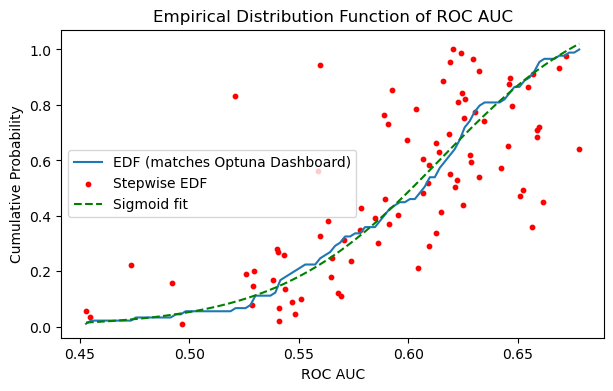

In [7]:
import numpy as np
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

roc_values = np.array([t.value for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])

# Step 1: define evenly spaced x-axis (like Optuna does)
NUM_SAMPLES_X_AXIS = 100  # same as Optuna's default
min_x_value = np.min(roc_values)
max_x_value = np.max(roc_values)
x_values = np.linspace(min_x_value, max_x_value, NUM_SAMPLES_X_AXIS)

# Step 2: compute EDF at each x_value


y_values = np.sum(roc_values[:, np.newaxis] <= x_values, axis=0) / len(roc_values)

# Trials \ X values| min_x_value ... max_x_value
#  ----------------+----------------------------          ^
#   0              |      F       F       T               |
#   .              |      F       T       T               |
#   .              |      F       F       F               |
#   .              |      T       T       T               |
#  n-1             |      F       F       F        Sum up True/False values
# ----------------------------------------------
#                  |   y_value   ...   y_value
#                  |      1       2        3


def sigmoid(x, L, x0, k):
    """
    Sigmoid function
    L: maximum value (asymptote)
    x0: midpoint (inflection)
    k: steepness
    """
    return L / (1 + np.exp(-k*(x - x0)))

# ----------  Fit sigmoid to EDF ----------
p0 = [1.0, np.mean(roc_values), 10.0]
params,_ = curve_fit(sigmoid,x_values,y_values,p0=p0,)
L, x0, k = params
def inv_sigmoid(y, L, x0, k):
    return x0 - (1/k) * np.log(L/y - 1)

def predict_roc_auc(trial_pos):
    # 1-indexed
    while trial_pos/(len(roc_values))>=L:
        trial_pos -=1
            
    return inv_sigmoid(trial_pos/(len(roc_values)),*params)

print(L)
print(f"R squared of sigmoid fit: {r2_score(y_values,sigmoid(x_values,*params)):.4f}")

for i in range(10):
    print(f"Predicted ROC AUC for next {i} trial: {predict_roc_auc(len(roc_values)+i):.4f}")
# ----------  Plot ----------
plt.figure(figsize=(7,4))
plt.plot(x_values, y_values, label='EDF (matches Optuna Dashboard)')
plt.scatter(roc_values, np.arange(1, len(roc_values)+1)/len(roc_values),
            color='red', label='Stepwise EDF',s=10)
plt.plot(x_values, sigmoid(x_values, *params), '--', color='green', label='Sigmoid fit')
plt.xlabel('ROC AUC')
plt.ylabel('Cumulative Probability')
plt.title('Empirical Distribution Function of ROC AUC')
plt.legend()
plt.show()

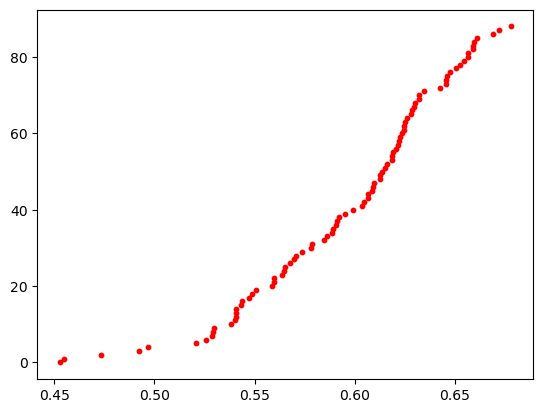

In [8]:
plt.scatter(sorted(roc_values), np.arange(len(roc_values)),
            color='red', label='Stepwise EDF',s=10)
plt.show()

## Alternative Prediction

R squared of exp fit: 0.9490


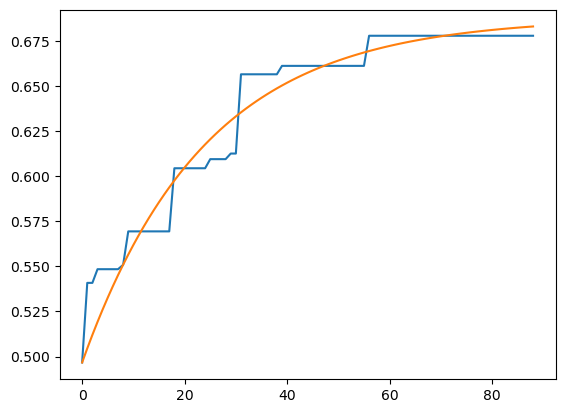

Predicted ROC AUC for next 0 trial: 0.6831
Predicted ROC AUC for next 1 trial: 0.6833
Predicted ROC AUC for next 2 trial: 0.6835
Predicted ROC AUC for next 3 trial: 0.6837
Predicted ROC AUC for next 4 trial: 0.6839
Predicted ROC AUC for next 5 trial: 0.6840
Predicted ROC AUC for next 6 trial: 0.6842
Predicted ROC AUC for next 7 trial: 0.6844
Predicted ROC AUC for next 8 trial: 0.6845
Predicted ROC AUC for next 9 trial: 0.6847


In [20]:
from scipy.optimize import curve_fit
best_so_far = []
best_val = float('-inf')

for t in study.trials:
    if (t.value is not None) and (t.state == optuna.trial.TrialState.COMPLETE):
        if t.value > best_val:
            best_val = t.value
        best_so_far.append(best_val)
y0 = best_so_far[0]
x = np.arange(len(best_so_far))
def exp_curve(x,y_inf,k):
    return y_inf - (y_inf-y0)*np.exp(-k*x)
params,_ = curve_fit(exp_curve,x,best_so_far)
print(f"R squared of exp fit: {r2_score(best_so_far,exp_curve(x,*params)):.4f}")
plt.plot(best_so_far)
plt.plot(exp_curve(x,*params))
plt.show()

for i in range(10):
    print(f"Predicted ROC AUC for next {i} trial: {exp_curve(len(best_so_far)+i-1,*params):.4f}")

In [42]:
trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE][-10:]

for trial in trials:
    print(f"\n  Trial number: {trial.number}")
    print(f"  Value (ROC AUC): {trial.value:.4f}")
    print(f"  Parameters: {trial.params}")


  Trial number: 229
  Value (ROC AUC): 0.6475
  Parameters: {'lr': 0.005653124850206031, 'weight_decay': 0.0022793514532808115, 'batch_size': 64, 'optimiser_name': 'Adam'}

  Trial number: 230
  Value (ROC AUC): 0.6227
  Parameters: {'lr': 0.007605999988345177, 'weight_decay': 0.001600055663791603, 'batch_size': 64, 'optimiser_name': 'Adam'}

  Trial number: 232
  Value (ROC AUC): 0.6260
  Parameters: {'lr': 0.008925181423427882, 'weight_decay': 0.0014427169992760197, 'batch_size': 32, 'optimiser_name': 'Adam'}

  Trial number: 234
  Value (ROC AUC): 0.5210
  Parameters: {'lr': 0.0019404430805040908, 'weight_decay': 0.012799568230075367, 'batch_size': 16, 'optimiser_name': 'SGD', 'momentum': 0.3283577119210519, 'scheduler_factor': 0.31927404938145787}

  Trial number: 235
  Value (ROC AUC): 0.6245
  Parameters: {'lr': 0.006942309516908816, 'weight_decay': 0.0005960542676090157, 'batch_size': 128, 'optimiser_name': 'AdamW'}

  Trial number: 236
  Value (ROC AUC): 0.5923
  Parameters: {